# Text-JEPA Fine-tuning & Evaluation Pipeline
## Product Review Rating Prediction (Brazilian E-Commerce)

**Architecture**: Text-JEPA (Joint Embedding Predictive Architecture — Text-only adaptation of VL-JEPA)  
**Hardware Target**: RTX 5060 Ti 16 GB (sm_120, Blackwell, CUDA 13)  
**Dataset**: Brazilian e-commerce product reviews (`translated_nlp_dataset.jsonl`)  
  - 44,234 samples · review text (English translation) + star rating (1–5)  
**Task**: Predict the star rating (1–5) from a review text via discriminative embedding matching.

---

### Architecture Mapping (VL-JEPA → Text-JEPA)
| VL-JEPA Component | Role | Text-JEPA Mapping |
|---|---|---|
| X-Encoder | Visual context → embedding | Frozen BERT encodes **review text** → context embedding |
| Predictor | (context, query) → target̂ | Trainable Transformer maps context + query → predicted rating embedding |
| Y-Encoder | Target text → embedding | Frozen BERT encodes **rating label** ("5 stars", etc.) → target embedding |
| Y-Decoder | Embedding → text | Not needed — discriminative inference only |

**Objective**: `BiDirectional InfoNCE Loss`  
**Inference**: Cosine similarity between predicted embedding and pre-computed candidate label embeddings.

---
*Pipeline: Environment Setup → Data Loading → Architecture → Loss → Training → Evaluation*

## Phase 0: Environment Setup & Hardware Configuration

In [1]:
# ─── Install dependencies if needed ───────────────────────────────────────────
# !pip install transformers sentencepiece scikit-learn tqdm

import os, json, random
from collections import Counter
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.cuda.amp import autocast, GradScaler
from tqdm.auto import tqdm

from transformers import AutoTokenizer, AutoModel
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score,
    confusion_matrix, classification_report
)

# ─── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ─── Hardware Setup (RTX 5060 Ti / Blackwell sm_120) ──────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    # TF32 — fastest FP32-level matmul on Blackwell / Ampere+
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.backends.cudnn.benchmark = True    # auto-tune kernels for fixed input sizes

# ─── Paths ────────────────────────────────────────────────────────────────────
DATA_PATH  = "translated_nlp_dataset.jsonl"  # adjust if needed
SAVE_DIR   = Path("/home/labib/Desktop/labib_codes/uiu_codes/7th_trimester/"
                  "da_project/da_project_local/notebooks/nlp_evaluation/vljepa/")
SAVE_DIR.mkdir(parents=True, exist_ok=True)
print(f"Save dir: {SAVE_DIR}")

/home/labib/Desktop/labib_codes/uiu_codes/7th_trimester/da_project/da_project_local/.da_project/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device : cuda
GPU    : NVIDIA GeForce RTX 5060 Ti
VRAM   : 16.6 GB
Save dir: /home/labib/Desktop/labib_codes/uiu_codes/7th_trimester/da_project/da_project_local/notebooks/nlp_evaluation/vljepa


## Phase 1: Data Loading, Deduplication & Stratified Splitting

The raw JSONL has **44,234 rows** but duplicated `order_id` entries.  
We deduplicate by `order_id` (keep first), then do a **stratified 80/10/10 split** so each star-score class is proportionally represented.

In [2]:
# ─── Load & Deduplicate ───────────────────────────────────────────────────────
raw_records = []
seen_ids = set()

with open(DATA_PATH, "r", encoding="utf-8") as f:
    for line in f:
        rec = json.loads(line.strip())
        oid = rec["order_id"]
        if oid not in seen_ids:
            seen_ids.add(oid)
            raw_records.append(rec)

print(f"After dedup : {len(raw_records):,} unique reviews")

# ─── Build lists ──────────────────────────────────────────────────────────────
texts  = [r["english_translation"] for r in raw_records]
labels = [int(r["review_score"]) for r in raw_records]   # 1-5

dist = Counter(labels)
print("\nClass distribution:")
for k in sorted(dist):
    bar = "█" * (dist[k] // 300)
    print(f"  {k}★  {dist[k]:>5}  ({100*dist[k]/len(labels):4.1f}%)  {bar}")

# ─── Stratified 80 / 10 / 10 split ───────────────────────────────────────────
idx = list(range(len(texts)))
idx_trainval, idx_test = train_test_split(
    idx, test_size=0.10, stratify=labels, random_state=SEED
)
labels_trainval = [labels[i] for i in idx_trainval]
idx_train, idx_val = train_test_split(
    idx_trainval, test_size=0.111, stratify=labels_trainval, random_state=SEED  # 0.111 of 90% ≈ 10%
)

def subset(indices):
    return [texts[i] for i in indices], [labels[i] for i in indices]

train_texts, train_labels = subset(idx_train)
val_texts,   val_labels   = subset(idx_val)
test_texts,  test_labels  = subset(idx_test)

print(f"\nSplit → Train: {len(train_texts):,}  |  Val: {len(val_texts):,}  |  Test: {len(test_texts):,}")

After dedup : 37,426 unique reviews

Class distribution:
  1★   6897  (18.4%)  ██████████████████████
  2★   1882  ( 5.0%)  ██████
  3★   3234  ( 8.6%)  ██████████
  4★   5668  (15.1%)  ██████████████████
  5★  19745  (52.8%)  █████████████████████████████████████████████████████████████████

Split → Train: 29,944  |  Val: 3,739  |  Test: 3,743


## Phase 2: Tokenization & Dataset Construction

We use **`distilbert-base-uncased`** as the shared tokenizer for both the review text (context) and the rating label text (target).  
Each dataset item is a triplet:

$$\langle X_{\text{review}},\; X_{\text{query}},\; Y_{\text{label}} \rangle$$

- $X_{\text{review}}$ — tokenized English review (plays the role of the *visual* context in VL-JEPA)  
- $X_{\text{query}}$ — fixed prompt: *"What is the sentiment score of this review?"*  
- $Y_{\text{label}}$ — tokenized rating string: *"1 star"* … *"5 stars"*

In [3]:
# ─── Tokenizer (shared) ───────────────────────────────────────────────────────
MODEL_NAME   = "distilbert-base-uncased"          # lightweight, fast, good English coverage
MAX_TEXT_LEN = 128                                 # review tokens
MAX_LABEL_LEN = 8                                  # "5 stars" = 3 tokens; 8 is safe
QUERY_TEXT   = "What is the sentiment score of this review?"
MAX_QUERY_LEN = 16

LABEL_STRINGS = [
    "1 star — very negative review",
    "2 stars — negative review",
    "3 stars — neutral review",
    "4 stars — positive review",
    "5 stars — very positive review",
]

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"Vocab size : {tokenizer.vocab_size:,}")

# ─── Sanity-check: tokenize one example ───────────────────────────────────────
sample_enc = tokenizer(
    train_texts[0], max_length=MAX_TEXT_LEN,
    padding="max_length", truncation=True, return_tensors="pt"
)
print(f"Token IDs shape : {sample_enc['input_ids'].shape}")
print(f"Decoded sample  : {tokenizer.decode(sample_enc['input_ids'][0][:20])}...")

Vocab size : 30,522
Token IDs shape : torch.Size([1, 128])
Decoded sample  : [CLS] nice watch, modern and sturdy design. only the temperature needle didn ’ t work. [SEP] [PAD]...


In [4]:
class ReviewRatingDataset(Dataset):
    """
    Returns tokenized triplets: (review_input_ids, query_input_ids, label_input_ids, label_int)
    
    - review_input_ids : [MAX_TEXT_LEN]   — review text tokens (X_context / X_V analogue)
    - query_input_ids  : [MAX_QUERY_LEN]  — fixed query prompt tokens (X_Q)
    - label_input_ids  : [MAX_LABEL_LEN]  — rating label tokens (Y)
    - label_int        : int (1–5)         — integer class for sampler / metrics
    """

    def __init__(self, texts, labels, tokenizer,
                 max_text=MAX_TEXT_LEN,
                 max_query=MAX_QUERY_LEN,
                 max_label=MAX_LABEL_LEN):
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_text  = max_text
        self.max_query = max_query
        self.max_label = max_label

        # Pre-tokenize review texts (slow once, fast during training)
        print("Pre-tokenizing reviews …")
        enc = tokenizer(
            texts,
            max_length=max_text, padding="max_length",
            truncation=True, return_tensors="pt"
        )
        self.review_ids       = enc["input_ids"]       # [N, max_text]
        self.review_attn_mask = enc["attention_mask"]  # [N, max_text]

        # Pre-tokenize the fixed query once
        q_enc = tokenizer(
            QUERY_TEXT,
            max_length=max_query, padding="max_length",
            truncation=True, return_tensors="pt"
        )
        self.query_ids  = q_enc["input_ids"].squeeze(0)       # [max_query]
        self.query_mask = q_enc["attention_mask"].squeeze(0)  # [max_query]

        # Pre-tokenize the 5 label strings
        l_enc = tokenizer(
            LABEL_STRINGS,
            max_length=max_label, padding="max_length",
            truncation=True, return_tensors="pt"
        )
        self.all_label_ids  = l_enc["input_ids"]       # [5, max_label]
        self.all_label_mask = l_enc["attention_mask"]  # [5, max_label]
        print("Done.")

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        label_int = self.labels[idx]          # 1-5
        label_idx = label_int - 1             # 0-4
        return (
            self.review_ids[idx],             # [max_text]
            self.review_attn_mask[idx],       # [max_text]
            self.query_ids,                   # [max_query]  — same for all
            self.query_mask,                  # [max_query]
            self.all_label_ids[label_idx],    # [max_label]
            self.all_label_mask[label_idx],   # [max_label]
            label_int                         # scalar int
        )


# ─── Instantiate ──────────────────────────────────────────────────────────────
train_dataset = ReviewRatingDataset(train_texts, train_labels, tokenizer)
val_dataset   = ReviewRatingDataset(val_texts,   val_labels,   tokenizer)
test_dataset  = ReviewRatingDataset(test_texts,  test_labels,  tokenizer)

Pre-tokenizing reviews …
Done.
Pre-tokenizing reviews …
Done.
Pre-tokenizing reviews …
Done.


In [5]:
# ─── Weighted Sampler to handle class imbalance (5★ is ~50% of data) ─────────
class_counts = Counter(train_labels)
n_classes    = 5
class_weights = {cls: 1.0 / count for cls, count in class_counts.items()}
sample_weights = [class_weights[lbl] for lbl in train_labels]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

BATCH_SIZE = 32   # fits comfortably in 16 GB VRAM with DistilBERT + Predictor
NUM_WORKERS = 4   # adjust to your CPU count

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE,
    sampler=sampler, pin_memory=True,
    num_workers=NUM_WORKERS, persistent_workers=True
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE,
    shuffle=False, pin_memory=True,
    num_workers=NUM_WORKERS, persistent_workers=True
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE,
    shuffle=False, pin_memory=True,
    num_workers=NUM_WORKERS, persistent_workers=True
)

print(f"Train batches : {len(train_loader):,}")
print(f"Val   batches : {len(val_loader):,}")
print(f"Test  batches : {len(test_loader):,}")

# Effective class balance check
print("\nEffective weight per class:")
for k in sorted(class_counts):
    print(f"  {k}★ : {class_weights[k]:.5f}")

Train batches : 936
Val   batches : 117
Test  batches : 117

Effective weight per class:
  1★ : 0.00018
  2★ : 0.00066
  3★ : 0.00039
  4★ : 0.00022
  5★ : 0.00006


## Phase 3: Model Architecture — Text-JEPA

```
Review Text ──► [X-Encoder: frozen DistilBERT] ──► context_emb  ─┐
                                                                   ├──► [Predictor: trainable Transformer] ──► ŝ_Y
Query Tokens ─────────────────────────────────────────────────────┘

Label Text ───► [Y-Encoder: frozen DistilBERT] ──► s_Y

Loss: BiDirectional InfoNCE(ŝ_Y, s_Y)
```

**Memory strategy**: X-Encoder and Y-Encoder share the same pre-trained DistilBERT weights (frozen).  
Only the **Predictor** (a 4-layer Transformer + projection head) is trained — ~12M params vs ~66M frozen.

In [6]:
class FrozenEncoder(nn.Module):
    """
    Shared frozen DistilBERT encoder.
    Returns mean-pooled [CLS]-excluded representation → [B, hidden_dim].
    We use mean pooling over non-padding tokens for richer representations.
    """
    def __init__(self, model_name: str = MODEL_NAME):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        self.hidden_dim = self.bert.config.hidden_size  # 768 for distilbert-base

        # Freeze all parameters
        for param in self.bert.parameters():
            param.requires_grad = False
        self.eval()  # always in eval mode

    @torch.no_grad()
    def forward(self, input_ids: torch.Tensor,
                attention_mask: torch.Tensor) -> torch.Tensor:
        """
        input_ids      : [B, L]
        attention_mask : [B, L]  (1 = real token, 0 = padding)
        Returns        : [B, hidden_dim]  — mean-pooled embedding
        """
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        # last_hidden_state: [B, L, H]
        token_embs = out.last_hidden_state                     # [B, L, H]
        mask_exp   = attention_mask.unsqueeze(-1).float()      # [B, L, 1]
        sum_emb    = (token_embs * mask_exp).sum(dim=1)        # [B, H]
        count      = mask_exp.sum(dim=1).clamp(min=1e-9)       # [B, 1]
        return sum_emb / count                                  # [B, H]


class TextJEPAPredictor(nn.Module):
    """
    The Predictor: maps (context_embedding, query_tokens) → predicted target embedding ŝ_Y.

    Architecture:
      1. Project context_emb (from X-Encoder) into predictor dim.
      2. Embed query tokens into predictor dim.
      3. Concatenate [context_proj; query_emb] → feed into Transformer encoder.
      4. Mean-pool non-padding outputs → project to shared embedding space.
      5. L2-normalize for InfoNCE cosine similarity.
    """

    def __init__(
        self,
        vocab_size:    int = 30522,        # DistilBERT vocab size
        encoder_dim:   int = 768,          # FrozenEncoder output dim
        predictor_dim: int = 512,          # internal predictor width
        out_dim:       int = 256,          # shared embedding space dim
        n_heads:       int = 8,
        n_layers:      int = 4,
        dropout:       float = 0.1,
    ):
        super().__init__()
        self.predictor_dim = predictor_dim
        self.out_dim       = out_dim

        # Project frozen context embedding into predictor space → 1 token
        self.context_proj = nn.Sequential(
            nn.Linear(encoder_dim, predictor_dim),
            nn.LayerNorm(predictor_dim),
        )

        # Query token embedding (learned, not frozen)
        self.query_embed = nn.Embedding(vocab_size, predictor_dim, padding_idx=0)

        # Core Transformer — bi-directional (no causal mask) so context attends to query
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=predictor_dim, nhead=n_heads,
            dim_feedforward=predictor_dim * 4,
            dropout=dropout, batch_first=True, norm_first=True  # Pre-LN for stability
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)

        # Output projection to shared embedding space
        self.out_proj = nn.Sequential(
            nn.Linear(predictor_dim, predictor_dim),
            nn.GELU(),
            nn.Linear(predictor_dim, out_dim),
        )

    def forward(
        self,
        context_emb:  torch.Tensor,  # [B, encoder_dim] from frozen X-Encoder
        query_ids:    torch.Tensor,  # [B, L_q]  tokenized query
        query_mask:   torch.Tensor,  # [B, L_q]  1=real, 0=pad
    ) -> torch.Tensor:               # [B, out_dim] normalized

        B = context_emb.size(0)

        # 1. Context token: project to [B, 1, predictor_dim]
        ctx_tok = self.context_proj(context_emb).unsqueeze(1)  # [B, 1, D]
        ctx_mask = torch.ones(B, 1, device=context_emb.device) # [B, 1] — always real

        # 2. Query tokens: [B, L_q, D]
        q_tok = self.query_embed(query_ids)                    # [B, L_q, D]

        # 3. Concatenate context + query → [B, 1+L_q, D]
        combined     = torch.cat([ctx_tok, q_tok], dim=1)         # [B, 1+L_q, D]
        combined_mask = torch.cat([ctx_mask, query_mask], dim=1)  # [B, 1+L_q]

        # 4. Transformer with key-padding mask (True = ignore/padding)
        pad_mask = combined_mask == 0                             # [B, 1+L_q] bool
        tf_out   = self.transformer(combined, src_key_padding_mask=pad_mask)  # [B, 1+L_q, D]

        # 5. Mean-pool over non-padding positions
        real_mask = (~pad_mask).unsqueeze(-1).float()             # [B, 1+L_q, 1]
        pooled    = (tf_out * real_mask).sum(1) / real_mask.sum(1).clamp(min=1e-9)  # [B, D]

        # 6. Project + L2-normalize for cosine space
        s_hat_y = self.out_proj(pooled)                          # [B, out_dim]
        return F.normalize(s_hat_y, p=2, dim=-1)                 # [B, out_dim]


class TextJEPA(nn.Module):
    """
    Full Text-JEPA model:
      - shared_encoder : FrozenEncoder (DistilBERT) used as both X-Encoder and Y-Encoder
      - predictor      : TextJEPAPredictor (trainable)
      - y_out_proj     : small trainable head on top of frozen Y-Encoder output
                         maps Y-encoder dim → shared embedding space
    """

    def __init__(self, model_name=MODEL_NAME, out_dim=256):
        super().__init__()
        self.shared_encoder = FrozenEncoder(model_name)
        enc_dim = self.shared_encoder.hidden_dim  # 768

        self.predictor = TextJEPAPredictor(
            vocab_size    = tokenizer.vocab_size,
            encoder_dim   = enc_dim,
            predictor_dim = 512,
            out_dim       = out_dim,
            n_heads       = 8,
            n_layers      = 4,
        )

        # Trainable projection on Y-encoder output (LR multiplier 0.05 per paper §3.1)
        self.y_proj = nn.Sequential(
            nn.Linear(enc_dim, out_dim),
            nn.GELU(),
            nn.Linear(out_dim, out_dim),
        )

    def encode_target(
        self,
        label_ids:  torch.Tensor,  # [B, L_y]
        label_mask: torch.Tensor,  # [B, L_y]
    ) -> torch.Tensor:             # [B, out_dim] normalized
        """
        Y-Encoder path: frozen BERT + trainable projection → normalized embedding.
        """
        s_y_raw = self.shared_encoder(label_ids, label_mask)  # [B, 768]
        s_y     = self.y_proj(s_y_raw)                        # [B, out_dim]
        return F.normalize(s_y, p=2, dim=-1)

    def forward(
        self,
        review_ids:   torch.Tensor,  # [B, max_text]
        review_mask:  torch.Tensor,  # [B, max_text]
        query_ids:    torch.Tensor,  # [B, max_query]
        query_mask:   torch.Tensor,  # [B, max_query]
    ) -> torch.Tensor:               # [B, out_dim] normalized
        """
        Predictor path: frozen BERT on review → context emb → Predictor → ŝ_Y.
        """
        context_emb = self.shared_encoder(review_ids, review_mask)  # [B, 768]
        s_hat_y     = self.predictor(context_emb, query_ids, query_mask)
        return s_hat_y


# ─── Instantiate & count parameters ──────────────────────────────────────────
model = TextJEPA().to(device)

def count_params(m, trainable_only=False):
    return sum(p.numel() for p in m.parameters()
               if not trainable_only or p.requires_grad)

print(f"Total params     : {count_params(model):>12,}")
print(f"  Frozen encoder : {count_params(model.shared_encoder):>12,}")
print(f"  Predictor      : {count_params(model.predictor):>12,}  ← TRAINABLE")
print(f"  Y-Proj head    : {count_params(model.y_proj):>12,}  ← TRAINABLE")
print(f"Trainable total  : {count_params(model, trainable_only=True):>12,}")

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 10579.12it/s]
[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/tmp/ipykernel_81175/1175906329.py:75: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


Total params     :   95,651,072
  Frozen encoder :   66,362,880
  Predictor      :   29,025,536  ← TRAINABLE
  Y-Proj head    :      262,656  ← TRAINABLE
Trainable total  :   29,288,192


## Phase 4: Objective Function — BiDirectional InfoNCE

InfoNCE loss operates on a **(B × B)** cosine similarity matrix.
- **Diagonal** = positive pairs (predicted ↔ ground-truth embedding for the same sample).
- **Off-diagonal** = negative pairs within the batch.

Bi-directional: loss is computed in both directions (predictor→target and target→predictor) and averaged.

$$\mathcal{L}_{\text{InfoNCE}} = -\frac{1}{2}\left(
  \mathbb{E}_{i}\log\frac{e^{s(\hat{s}_i, s_i)/\tau}}{\sum_j e^{s(\hat{s}_i, s_j)/\tau}}
  +
  \mathbb{E}_{i}\log\frac{e^{s(s_i, \hat{s}_i)/\tau}}{\sum_j e^{s(s_i, \hat{s}_j)/\tau}}
\right)$$

In [7]:
class BiDirectionalInfoNCELoss(nn.Module):
    """
    Bi-directional InfoNCE loss.

    Both s_hat_y and s_y must already be L2-normalized.
    The temperature τ is a learned parameter (log-parameterized to keep it > 0),
    following the CLIP convention — initialized to log(1/0.07) ≈ 2.66.
    """

    def __init__(self, init_temperature: float = 0.07, learnable: bool = True):
        super().__init__()
        log_temp = torch.tensor(np.log(1.0 / init_temperature), dtype=torch.float32)
        if learnable:
            self.log_temperature = nn.Parameter(log_temp)
        else:
            self.register_buffer("log_temperature", log_temp)
        # Clamp range: τ ∈ [0.01, 0.5]
        self.log_temp_min = np.log(1.0 / 0.5)
        self.log_temp_max = np.log(1.0 / 0.01)

    @property
    def temperature(self):
        log_t = self.log_temperature.clamp(self.log_temp_min, self.log_temp_max)
        return 1.0 / log_t.exp()   # τ

    def forward(
        self,
        s_hat_y: torch.Tensor,   # [B, D] predictor output (L2-normed)
        s_y:     torch.Tensor,   # [B, D] target embedding  (L2-normed)
    ) -> torch.Tensor:
        tau    = self.temperature
        logits = torch.matmul(s_hat_y, s_y.T) / tau   # [B, B]
        labels = torch.arange(logits.size(0), device=logits.device)

        loss_fwd = F.cross_entropy(logits,   labels)  # predict → target
        loss_bwd = F.cross_entropy(logits.T, labels)  # target → predict
        return (loss_fwd + loss_bwd) / 2.0


criterion = BiDirectionalInfoNCELoss(init_temperature=0.07, learnable=True).to(device)
print(f"Initial temperature τ = {criterion.temperature.item():.4f}")

Initial temperature τ = 0.0700


## Phase 5: Optimiser, Scheduler & Mixed-Precision Setup

- **AdamW** with **weight-decay** on Predictor + Y-Proj + temperature parameter.
- Y-Proj gets a **smaller learning rate** (×0.05 multiplier) following §3.1 of the paper, since the quality of embedding prediction is unstable in early training.
- **Gradient clipping** at `max_norm=1.0`.
- **AMP (BF16)** for RTX 5060 Ti / Blackwell — BF16 is native and avoids the overflow risks of FP16.

In [8]:
# ─── Learning rate groups (per §3.1 of VL-JEPA paper) ─────────────────────────
LR_PREDICTOR = 3e-4
LR_Y_PROJ    = LR_PREDICTOR * 0.05   # slow-start for Y-projection head
LR_TEMP      = 1e-3                  # temperature can move fast

param_groups = [
    {"params": model.predictor.parameters(),     "lr": LR_PREDICTOR, "name": "predictor"},
    {"params": model.y_proj.parameters(),        "lr": LR_Y_PROJ,    "name": "y_proj"},
    {"params": criterion.parameters(),           "lr": LR_TEMP,      "name": "temperature"},
]

optimizer = torch.optim.AdamW(
    param_groups,
    weight_decay=1e-2,
    fused=torch.cuda.is_available()   # fused kernel on CUDA for speed
)

EPOCHS    = 10
WARMUP    = 2    # linear warm-up epochs
TOTAL_STEPS = EPOCHS * len(train_loader)

def lr_lambda(step):
    """Linear warm-up then cosine annealing."""
    warmup_steps = WARMUP * len(train_loader)
    if step < warmup_steps:
        return step / max(1, warmup_steps)
    progress = (step - warmup_steps) / max(1, TOTAL_STEPS - warmup_steps)
    return 0.5 * (1 + np.cos(np.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

# ─── AMP (BF16 preferred on Blackwell) ────────────────────────────────────────
USE_AMP   = torch.cuda.is_available()
AMP_DTYPE = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
scaler    = GradScaler(enabled=(AMP_DTYPE == torch.float16))  # scaler only for fp16

print(f"AMP dtype  : {AMP_DTYPE}")
print(f"Epochs     : {EPOCHS}")
print(f"Total steps: {TOTAL_STEPS:,}")
print(f"Warmup     : {WARMUP * len(train_loader):,} steps")

AMP dtype  : torch.bfloat16
Epochs     : 10
Total steps: 9,360
Warmup     : 1,872 steps


/tmp/ipykernel_81175/3636311259.py:35: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = GradScaler(enabled=(AMP_DTYPE == torch.float16))  # scaler only for fp16


## Phase 6: Training & Validation Loop

Each step:
1. Forward pass through frozen X-Encoder + Predictor → `ŝ_Y`  
2. Forward pass through frozen Y-Encoder + trainable Y-Proj → `s_Y`  
3. BiDirectional InfoNCE loss → backward → gradient clip → step  
4. Checkpointing: saves **Predictor + Y-Proj + temperature** (not the frozen encoder)

In [10]:
history = {"train_loss": [], "val_loss": [], "val_acc": [], "temperature": []}
best_val_loss = float("inf")

for epoch in range(1, EPOCHS + 1):

    # ── TRAIN ──────────────────────────────────────────────────────────────────
    model.train()
    criterion.train()
    total_loss = 0.0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch:02d}/{EPOCHS} [Train]")
    for batch in pbar:
        (
            rev_ids, rev_mask,
            q_ids, q_mask,
            lbl_ids, lbl_mask,
            _
        ) = [x.to(device, non_blocking=True) for x in batch]

        optimizer.zero_grad(set_to_none=True)

        # FIX: Updated to the modern torch.amp.autocast API
        with torch.amp.autocast("cuda", dtype=AMP_DTYPE, enabled=USE_AMP):
            # Predictor path
            s_hat_y = model(rev_ids, rev_mask, q_ids, q_mask)   # [B, out_dim]
            # Y-Encoder path (frozen BERT, trainable y_proj)
            s_y     = model.encode_target(lbl_ids, lbl_mask)    # [B, out_dim]
            loss    = criterion(s_hat_y, s_y)

        scaler.scale(loss).backward()
        # Gradient clipping — applied after unscaling
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(
            [p for group in param_groups for p in group["params"]],
            max_norm=1.0
        )
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        total_loss += loss.item()
        pbar.set_postfix({"loss": f"{loss.item():.4f}",
                          "τ": f"{criterion.temperature.item():.4f}",
                          "lr": f"{scheduler.get_last_lr()[0]:.2e}"})

    avg_train_loss = total_loss / len(train_loader)

    # ── VALIDATE ───────────────────────────────────────────────────────────────
    model.eval()
    criterion.eval()
    val_loss  = 0.0
    all_preds = []
    all_lbls  = []

    # Pre-compute all 5 candidate label embeddings (only once per epoch)
    with torch.no_grad():
        cand_ids  = val_dataset.all_label_ids.to(device)   # [5, max_label]
        cand_mask = val_dataset.all_label_mask.to(device)  # [5, max_label]
        cand_embs = model.encode_target(cand_ids, cand_mask)  # [5, out_dim]

    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f"Epoch {epoch:02d}/{EPOCHS} [Val]  "):
            (
                rev_ids, rev_mask,
                q_ids, q_mask,
                lbl_ids, lbl_mask,
                labels_int
            ) = [x.to(device, non_blocking=True) for x in batch]

            # FIX: Updated to the modern torch.amp.autocast API
            with torch.amp.autocast("cuda", dtype=AMP_DTYPE, enabled=USE_AMP):
                s_hat_y = model(rev_ids, rev_mask, q_ids, q_mask)  # [B, D]
                s_y     = model.encode_target(lbl_ids, lbl_mask)   # [B, D]
                loss    = criterion(s_hat_y, s_y)

            val_loss += loss.item()

            # Discriminative inference: nearest candidate label
            sims  = torch.matmul(s_hat_y, cand_embs.T)   # [B, 5]
            preds = sims.argmax(dim=1) + 1                # 1-5

            all_preds.extend(preds.cpu().numpy())
            all_lbls.extend(labels_int.cpu().numpy())

    avg_val_loss = val_loss / len(val_loader)
    val_acc      = accuracy_score(all_lbls, all_preds)
    tau          = criterion.temperature.item()

    history["train_loss"].append(avg_train_loss)
    history["val_loss"].append(avg_val_loss)
    history["val_acc"].append(val_acc)
    history["temperature"].append(tau)

    print(
        f"Epoch {epoch:02d} │ "
        f"Train Loss: {avg_train_loss:.4f} │ "
        f"Val Loss: {avg_val_loss:.4f} │ "
        f"Val Acc: {val_acc*100:.2f}% │ "
        f"τ: {tau:.4f}"
    )

    # ── CHECKPOINT (best val loss) ─────────────────────────────────────────────
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        ckpt = {
            "epoch":       epoch,
            "val_loss":    avg_val_loss,
            "val_acc":     val_acc,
            "predictor":   model.predictor.state_dict(),
            "y_proj":      model.y_proj.state_dict(),
            "criterion":   criterion.state_dict(),
        }
        save_path = SAVE_DIR / "textjepa_predictor_best.pt"
        torch.save(ckpt, save_path)
        print(f"  ✅  Saved checkpoint → {save_path}")

print("\n✔ Training complete.")

Epoch 01/10 [Val]  : 100%|██████████| 117/117 [00:02<00:00, 52.28it/s]


Epoch 01 │ Train Loss: 3.1487 │ Val Loss: 3.2285 │ Val Acc: 47.55% │ τ: 0.0678
  ✅  Saved checkpoint → /home/labib/Desktop/labib_codes/uiu_codes/7th_trimester/da_project/da_project_local/notebooks/nlp_evaluation/vljepa/textjepa_predictor_best.pt


Epoch 02/10 [Val]  : 100%|██████████| 117/117 [00:01<00:00, 60.60it/s]


Epoch 02 │ Train Loss: 3.0794 │ Val Loss: 3.0675 │ Val Acc: 58.28% │ τ: 0.0726
  ✅  Saved checkpoint → /home/labib/Desktop/labib_codes/uiu_codes/7th_trimester/da_project/da_project_local/notebooks/nlp_evaluation/vljepa/textjepa_predictor_best.pt


Epoch 03/10 [Val]  : 100%|██████████| 117/117 [00:01<00:00, 60.52it/s]


...

Epoch 08 │ Train Loss: 2.9730 │ Val Loss: 3.0554 │ Val Acc: 58.73% │ τ: 0.0877


Epoch 09/10 [Val]  : 100%|██████████| 117/117 [00:01<00:00, 61.00it/s]


Epoch 09 │ Train Loss: 2.9606 │ Val Loss: 3.0555 │ Val Acc: 58.12% │ τ: 0.0877


Epoch 10/10 [Val]  : 100%|██████████| 117/117 [00:01<00:00, 59.36it/s]

Epoch 10 │ Train Loss: 2.9510 │ Val Loss: 3.0578 │ Val Acc: 57.66% │ τ: 0.0878

✔ Training complete.


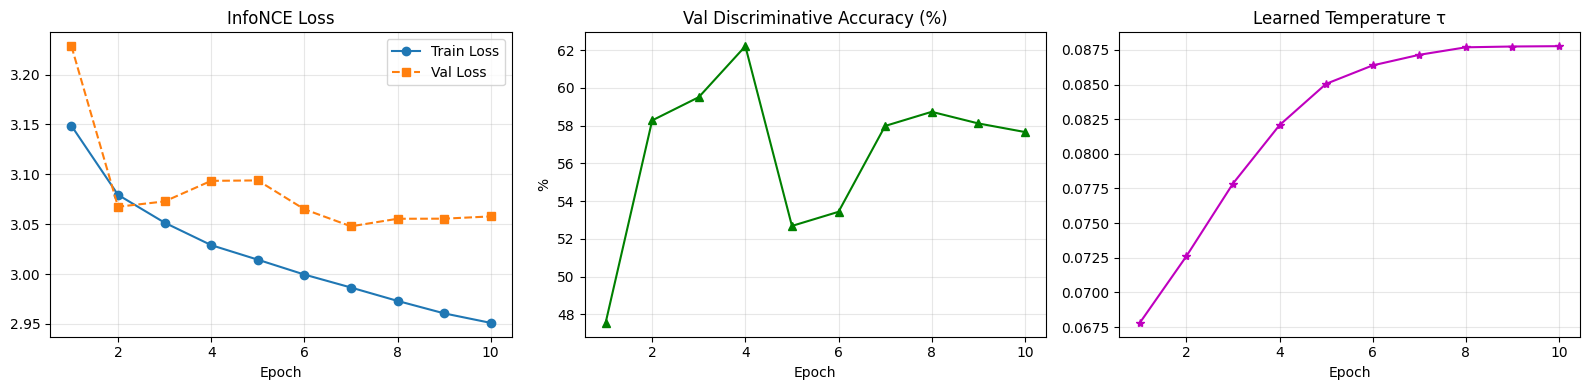

In [11]:
# ─── Plot training curves ────────────────────────────────────────────────────
import matplotlib.pyplot as plt

epochs_range = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(epochs_range, history["train_loss"], "o-", label="Train Loss")
axes[0].plot(epochs_range, history["val_loss"],   "s--", label="Val Loss")
axes[0].set_title("InfoNCE Loss"); axes[0].set_xlabel("Epoch")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, [a*100 for a in history["val_acc"]], "g^-")
axes[1].set_title("Val Discriminative Accuracy (%)"); axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("%"); axes[1].grid(True, alpha=0.3)

axes[2].plot(epochs_range, history["temperature"], "m*-")
axes[2].set_title("Learned Temperature τ"); axes[2].set_xlabel("Epoch")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(SAVE_DIR / "training_curves.png", dpi=150)
plt.show()

## Phase 7: Final Test Evaluation — Discriminative Inference

We **reload the best checkpoint**, pre-compute the 5 candidate label embeddings, and run inference on the held-out test set.

Metrics reported:
- **Exact accuracy** (1-of-5 classes)
- **Within-1 accuracy** (|pred − true| ≤ 1) — meaningful for ordinal ratings
- **Weighted F1** — accounts for class imbalance
- **Confusion matrix**
- **Per-class precision / recall / F1**

In [13]:
# ─── Reload best checkpoint ──────────────────────────────────────────────────
ckpt = torch.load(SAVE_DIR / "textjepa_predictor_best.pt", map_location=device)
model.predictor.load_state_dict(ckpt["predictor"])
model.y_proj.load_state_dict(ckpt["y_proj"])
criterion.load_state_dict(ckpt["criterion"])
print(f"Loaded checkpoint from epoch {ckpt['epoch']}  "
      f"(val loss {ckpt['val_loss']:.4f}, val acc {ckpt['val_acc']*100:.2f}%)")

# ─── Pre-compute candidate label embeddings ──────────────────────────────────
model.eval()
with torch.no_grad():
    cand_ids  = test_dataset.all_label_ids.to(device)   # [5, max_label]
    cand_mask = test_dataset.all_label_mask.to(device)  # [5, max_label]
    cand_embs = model.encode_target(cand_ids, cand_mask)  # [5, out_dim]

print("\nCandidate embedding cosine similarities (should form block structure):")
sim_matrix = torch.matmul(cand_embs, cand_embs.T).cpu().numpy()
for row in sim_matrix:
    print("  " + "  ".join(f"{v:+.3f}" for v in row))

# ─── Inference ───────────────────────────────────────────────────────────────
all_preds  = []
all_labels = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Test Inference"):
        (
            rev_ids, rev_mask,
            q_ids, q_mask,
            _, _,
            labels_int
        ) = [x.to(device, non_blocking=True) for x in batch]

        # FIX: Updated to the modern torch.amp.autocast API
        with torch.amp.autocast("cuda", dtype=AMP_DTYPE, enabled=USE_AMP):
            s_hat_y = model(rev_ids, rev_mask, q_ids, q_mask)  # [B, D]

        sims  = torch.matmul(s_hat_y, cand_embs.T)  # [B, 5]
        preds = sims.argmax(dim=1) + 1               # 1-5

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels_int.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

Loaded checkpoint from epoch 7  (val loss 3.0478, val acc 57.98%)

Candidate embedding cosine similarities (should form block structure):
  +1.000  +0.898  +0.811  +0.682  +0.651
  +0.898  +1.000  +0.911  +0.803  +0.657
  +0.811  +0.911  +1.000  +0.920  +0.785
  +0.682  +0.803  +0.920  +1.000  +0.922
  +0.651  +0.657  +0.785  +0.922  +1.000


Test Inference: 100%|██████████| 117/117 [00:01<00:00, 68.31it/s]


  TEST SET — Text-JEPA Discriminative Inference
  Exact Accuracy    :  59.10%
  Within-1 Accuracy :  90.70%   (|pred-true| ≤ 1)
  Weighted F1       : 0.6182
  Macro F1          : 0.4656

              precision    recall  f1-score   support

          1★       0.72      0.70      0.71       690
          2★       0.18      0.32      0.23       188
          3★       0.30      0.32      0.31       323
          4★       0.27      0.40      0.32       567
          5★       0.86      0.68      0.76      1975

    accuracy                           0.59      3743
   macro avg       0.47      0.48      0.47      3743
weighted avg       0.66      0.59      0.62      3743



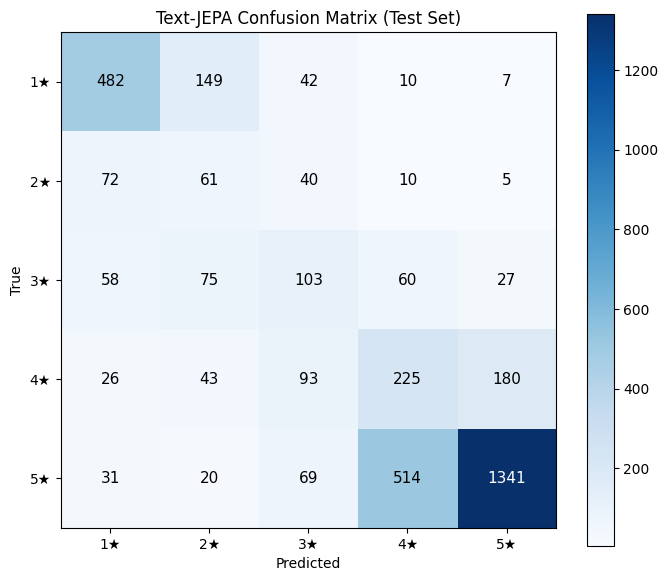

In [14]:
# ─── Metrics ─────────────────────────────────────────────────────────────────
exact_acc     = accuracy_score(all_labels, all_preds)
within1_acc   = np.mean(np.abs(all_preds - all_labels) <= 1)
weighted_f1   = f1_score(all_labels, all_preds, average="weighted")
macro_f1      = f1_score(all_labels, all_preds, average="macro")
cm            = confusion_matrix(all_labels, all_preds, labels=[1,2,3,4,5])

print("=" * 55)
print("  TEST SET — Text-JEPA Discriminative Inference")
print("=" * 55)
print(f"  Exact Accuracy    : {exact_acc*100:6.2f}%")
print(f"  Within-1 Accuracy : {within1_acc*100:6.2f}%   (|pred-true| ≤ 1)")
print(f"  Weighted F1       : {weighted_f1:.4f}")
print(f"  Macro F1          : {macro_f1:.4f}")
print()
print(classification_report(all_labels, all_preds,
                             target_names=[f"{i}★" for i in range(1, 6)]))

# ─── Confusion Matrix plot ────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap="Blues")
plt.colorbar(im, ax=ax)

tick_labels = [f"{i}★" for i in range(1, 6)]
ax.set_xticks(range(5)); ax.set_xticklabels(tick_labels)
ax.set_yticks(range(5)); ax.set_yticklabels(tick_labels)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Text-JEPA Confusion Matrix (Test Set)")

for i in range(5):
    for j in range(5):
        c = "white" if cm[i, j] > cm.max() * 0.6 else "black"
        ax.text(j, i, str(cm[i, j]), ha="center", va="center", color=c, fontsize=11)

plt.tight_layout()
fig.savefig(SAVE_DIR / "confusion_matrix.png", dpi=150)
plt.show()

## Phase 8: Embedding Space Inspection

Visualise how well the Predictor pushes test reviews toward their correct rating embeddings using t-SNE on the predicted embeddings coloured by true label.

Running t-SNE on 2005 points …


/tmp/ipykernel_81175/1740308023.py:44: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors  = cm.get_cmap("RdYlGn", 5)


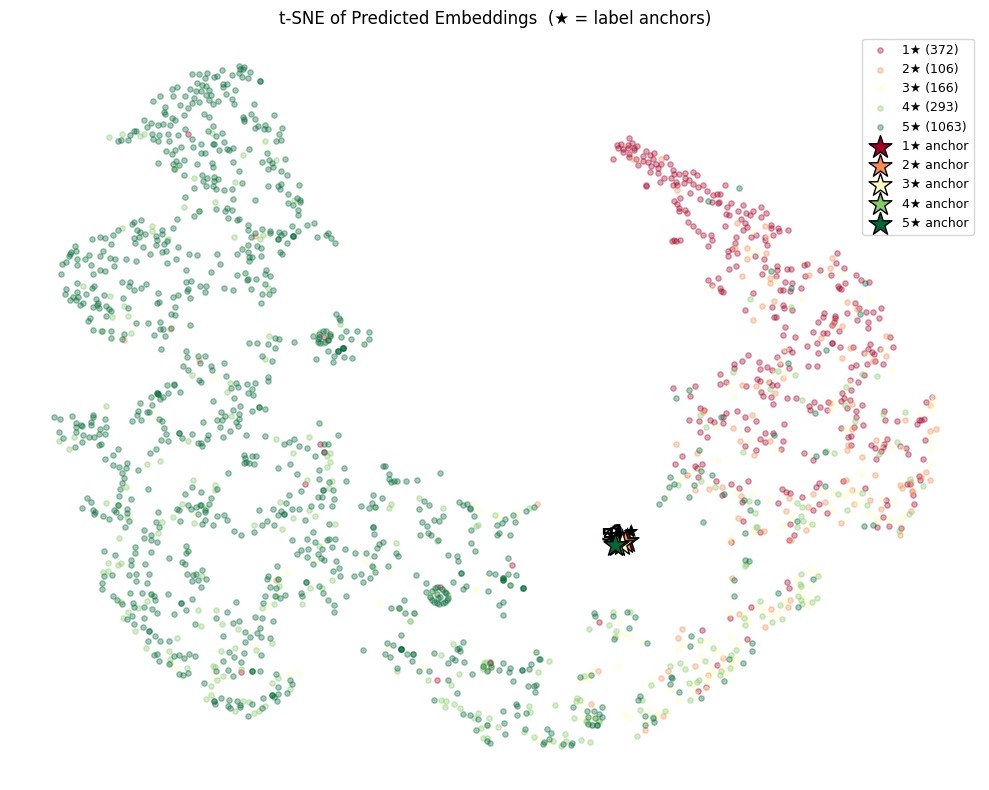

In [17]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import torch

# Collect predicted embeddings for the first 2000 test samples
N_TSNE = 2000
emb_list, lbl_list = [], []

model.eval()
with torch.no_grad():
    for batch in tqdm(test_loader, desc="Collecting embeddings", total=N_TSNE // BATCH_SIZE):
        (
            rev_ids, rev_mask,
            q_ids, q_mask,
            _, _,
            labels_int
        ) = [x.to(device, non_blocking=True) for x in batch]

        # Modern torch.amp.autocast API
        with torch.amp.autocast("cuda", dtype=AMP_DTYPE, enabled=USE_AMP):
            s_hat = model(rev_ids, rev_mask, q_ids, q_mask)  # [B, D]

        emb_list.append(s_hat.cpu().float().numpy())
        lbl_list.extend(labels_int.cpu().numpy())

        if len(lbl_list) >= N_TSNE:
            break

embs  = np.vstack(emb_list)[:N_TSNE]
lbls  = np.array(lbl_list)[:N_TSNE]

# Also add the 5 candidate embeddings for reference
cand_np = cand_embs.cpu().float().numpy()  # [5, D]
all_embs = np.vstack([embs, cand_np])

print(f"Running t-SNE on {len(embs) + 5} points …")
# FIX: Changed 'n_iter' to 'max_iter' for modern scikit-learn compatibility
tsne  = TSNE(n_components=2, perplexity=40, random_state=SEED, max_iter=1000)
proj  = tsne.fit_transform(all_embs)

fig, ax = plt.subplots(figsize=(10, 8))
colors  = cm.get_cmap("RdYlGn", 5)

for star in range(1, 6):
    mask = lbls == star
    ax.scatter(
        proj[:N_TSNE][mask, 0],
        proj[:N_TSNE][mask, 1],
        c=[colors(star - 1)], alpha=0.35, s=15,
        label=f"{star}★ ({mask.sum()})"
    )

# Plot candidate anchors with star markers
for i, star in enumerate(range(1, 6)):
    ax.scatter(
        proj[N_TSNE + i, 0], proj[N_TSNE + i, 1],
        c=[colors(i)], s=300, marker="*", edgecolors="black", zorder=5,
        label=f"{star}★ anchor"
    )
    ax.annotate(f"{star}★", (proj[N_TSNE + i, 0], proj[N_TSNE + i, 1]),
                fontsize=13, fontweight="bold", ha="center", va="bottom")

ax.set_title("t-SNE of Predicted Embeddings  (★ = label anchors)")
ax.legend(loc="upper right", fontsize=9)
ax.axis("off")
plt.tight_layout()
fig.savefig(SAVE_DIR / "tsne_embedding_space.png", dpi=150)
plt.show()

## Phase 9: Single-Sample Inference Demo

End-to-end inference on raw text input. Pass any review text and get: 
- predicted star rating  
- cosine similarity scores per class

In [18]:
def predict_rating(review_text: str, model, tokenizer, cand_embs, device) -> dict:
    """
    Run discriminative Text-JEPA inference on a single review string.
    Returns dict with predicted rating and per-class scores.
    """
    model.eval()

    # Tokenize review
    rev_enc = tokenizer(
        review_text, max_length=MAX_TEXT_LEN,
        padding="max_length", truncation=True, return_tensors="pt"
    )
    # Tokenize fixed query
    q_enc = tokenizer(
        QUERY_TEXT, max_length=MAX_QUERY_LEN,
        padding="max_length", truncation=True, return_tensors="pt"
    )

    rev_ids  = rev_enc["input_ids"].to(device)
    rev_mask = rev_enc["attention_mask"].to(device)
    q_ids    = q_enc["input_ids"].to(device)
    q_mask   = q_enc["attention_mask"].to(device)

    with torch.no_grad():
        s_hat_y = model(rev_ids, rev_mask, q_ids, q_mask)    # [1, D]
        sims    = torch.matmul(s_hat_y, cand_embs.T).squeeze(0)  # [5]

    sims_np = sims.cpu().numpy()
    pred_star = int(sims_np.argmax()) + 1

    return {
        "predicted_rating": pred_star,
        "scores": {f"{i+1}★": float(f"{s:.4f}") for i, s in enumerate(sims_np)},
    }


# ─── Demo reviews ────────────────────────────────────────────────────────────
demo_reviews = [
    "The product arrived on time and was exactly as described. Excellent quality, very happy!",
    "Total disappointment. The item broke on the first day. Do NOT buy this.",
    "Decent product for the price, though packaging was slightly damaged.",
    "It was okay. Nothing special but nothing terrible either.",
    "I've been waiting for 3 weeks and still haven't received my order. No response from support.",
]

print("=" * 60)
print("  DEMO: Single-Sample Discriminative Inference")
print("=" * 60)
for review in demo_reviews:
    result = predict_rating(review, model, tokenizer, cand_embs, device)
    stars  = "★" * result["predicted_rating"] + "☆" * (5 - result["predicted_rating"])
    print(f"\nReview  : {review[:80]}..." if len(review) > 80 else f"\nReview  : {review}")
    print(f"Predicted: {stars} ({result['predicted_rating']} stars)")
    print(f"Scores  : {result['scores']}")

  DEMO: Single-Sample Discriminative Inference

Review  : The product arrived on time and was exactly as described. Excellent quality, ver...
Predicted: ★★★★★ (5 stars)
Scores  : {'1★': 0.0947, '2★': 0.1078, '3★': 0.2729, '4★': 0.4682, '5★': 0.5832}

Review  : Total disappointment. The item broke on the first day. Do NOT buy this.
Predicted: ★☆☆☆☆ (1 stars)
Scores  : {'1★': 0.5633, '2★': 0.4848, '3★': 0.3973, '4★': 0.2342, '5★': 0.1524}

Review  : Decent product for the price, though packaging was slightly damaged.
Predicted: ★★★☆☆ (3 stars)
Scores  : {'1★': 0.2079, '2★': 0.3791, '3★': 0.5428, '4★': 0.5263, '5★': 0.3549}

Review  : It was okay. Nothing special but nothing terrible either.
Predicted: ★★★★☆ (4 stars)
Scores  : {'1★': 0.2448, '2★': 0.2927, '3★': 0.4687, '4★': 0.531, '5★': 0.5014}

Review  : I've been waiting for 3 weeks and still haven't received my order. No response f...
Predicted: ★☆☆☆☆ (1 stars)
Scores  : {'1★': 0.5863, '2★': 0.3909, '3★': 0.298, '4★': 0.1258, '5★': 0